<a href="https://colab.research.google.com/github/hanjeongseop/Data/blob/main/2_EDA(%ED%83%90%EC%83%89%EC%A0%81_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import subprocess
subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-nanum'])

import matplotlib
import shutil, os

cache_dir = matplotlib.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)
print("✓ 설치 완료. 런타임을 재시작하세요.")

✓ 설치 완료. 런타임을 재시작하세요.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"✓ 폰트 적용: {font_path}")

✓ 폰트 적용: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumGothic 폰트 경로 찾기
font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))

if font_path:
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    print(f"'NanumGothic' 폰트가 성공적으로 설정되었습니다: {font_path}")
else:
    print("'NanumGothic' 폰트를 찾을 수 없습니다. 폰트 설치 및 캐시 확인이 필요합니다.")

'NanumGothic' 폰트가 성공적으로 설정되었습니다: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


# II. EDA (탐색적 데이터 분석)

## 1. 주요 공정 인자에 따른 시각화

##     데이터 분석 계획 수립 : 각 공정 별 주요 영향인자 분석

In [4]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [5]:
# 파일 읽기 및 내용 확인하기

github_csv_url = 'https://raw.githubusercontent.com/hanjeongseop/Data/main'

df1 = pd.read_csv(github_csv_url + '/preprocessing_data.csv')

df1

,Unnamed: 0,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,target_binom,Chamber_Route
0,0,1,Oxidation,dry,1138.979159,O2,32.80,0.200,62.0,699.443,...,3.002593e+17,6.000007e+17,31574.410,102.847,885.0,154,96,none,0.0,route_11133
1,1,1,Oxidation,dry,1218.184551,O2,31.86,0.194,137.0,696.792,...,3.017903e+17,6.000012e+17,31580.213,104.323,919.0,154,102,none,0.0,route_11222
2,2,1,Oxidation,dry,1062.467808,O2,39.51,0.217,128.0,705.471,...,2.994231e+17,6.000002e+17,32162.414,100.605,916.0,155,95,none,0.0,route_11311
3,3,1,Oxidation,dry,1114.704773,O2,32.88,0.201,90.0,710.772,...,2.991354e+17,6.000003e+17,32874.925,101.739,911.0,156,117,none,0.0,route_12111
4,4,1,Oxidation,dry,989.411946,O2,38.11,0.204,98.0,716.975,...,3.005576e+17,6.000013e+17,30985.928,106.422,872.0,155,143,none,0.0,route_12222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,845,3,Oxidation,wet,1280.687973,H2O,45.19,0.214,21.0,708.586,...,2.995317e+17,5.999986e+17,32252.961,101.177,868.0,152,84,none,0.0,route_33111
748,846,3,Oxidation,wet,1275.153349,H2O,45.08,0.215,22.0,712.936,...,3.004926e+17,5.999991e+17,32253.818,100.736,868.0,151,105,none,0.0,route_33222
749,847,3,Oxidation,wet,1275.182502,H2O,45.10,0.214,21.0,715.498,...,3.009325e+17,6.000003e+17,32248.621,101.503,868.0,152,78,none,0.0,route_33333
750,848,1,Oxidation,wet,1268.105427,H2O,45.07,0.215,22.0,707.179,...,3.006733e+17,6.000003e+17,32241.426,101.061,867.0,152,42,none,0.0,route_11133


## 데이터 시각화 : 데이터 타입에 따라 시각화 기법이 달라진다.

1. 단일 변수 시각화
    - 연속형(숫자) : 데이터 분포 + 기술통계량 [ Histogram + KDE(확률밀도함수 : Kernel desity Estimator) ]
                                   사용방법 =>  sns.histplot(data= , x= , kde=True)
                                 + 상자그림 ( Box plot ) / Pair plot         
                                   사용방법 =>  sns.boxplot(data=, x= ) / sns.pairplot(data=)

    - 범주형(문자) : 데이터의 빈도수
                     sns.countplot(data= , x= )

2. 다변수 시각화
    - X : 범주형 / Y : 연속형  => 집단 간 통계량 비교
        (sns.barplot() / sns.boxplot() )
    - X : 연속형 / Y : 연속형  => 두 데이터 간 연관성
        (sns.scatterplot() -> 일반적으로 산점도에 회귀선을 추가해 시각화 한다)
    - X : 순서형(시간) / Y : 연속형
        (sns.lineplot())

<Axes: xlabel='Target', ylabel='Count'>

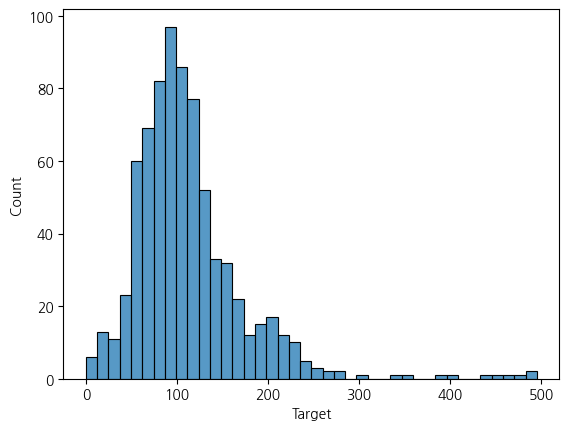

In [6]:
# Target(불량)을 사용해 시각화를 해보자

sns.histplot(data=df1, x='Target')

<Axes: xlabel='Target', ylabel='Count'>

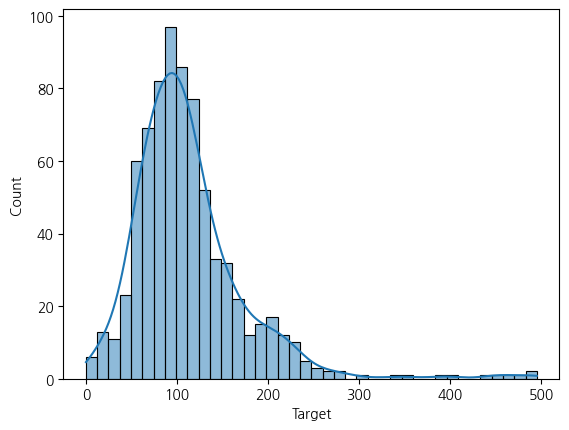

In [7]:
# 정규분포를 가지고 있는지 확인해보자

sns.histplot(data=df1, x='Target', kde=True)

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           752 non-null    int64  
 1   Ox_Chamber           752 non-null    int64  
 2   process              752 non-null    object 
 3   type                 752 non-null    object 
 4   Temp_OXid            752 non-null    float64
 5   Vapor                752 non-null    object 
 6   ppm                  752 non-null    float64
 7   Pressure             752 non-null    float64
 8   Oxid_time            752 non-null    float64
 9   thickness            752 non-null    float64
 10  No_Die               752 non-null    object 
 11  Reinforcement        752 non-null    bool   
 12  Unnamed: 0_x         752 non-null    int64  
 13  photo_soft_Chamber   752 non-null    int64  
 14  process 2            752 non-null    object 
 15  resist_target        752 non-null    flo

In [9]:
df1.columns

Index(['Unnamed: 0', 'Ox_Chamber', 'process', 'type', 'Temp_OXid', 'Vapor',
       'ppm', 'Pressure', 'Oxid_time', 'thickness', 'No_Die', 'Reinforcement',
       'Unnamed: 0_x', 'photo_soft_Chamber', 'process 2', 'resist_target',
       'N2_HMDS', 'pressure_HMDS', 'temp_HMDS', 'temp_HMDS_bake',
       'time_HMDS_bake', 'spin1', 'spin2', 'spin3', 'photoresist_bake',
       'temp_softbake', 'time_softbake', 'lithography_Chamber', 'Line_CD',
       'UV_type', 'Wavelength', 'Resolution', 'Energy_Exposure', 'Range_check',
       'Unnamed: 0_y', 'Etching_Chamber', 'Process 3', 'Temp_Etching',
       'Source_Power', 'Selectivity', 'Thin Film 4', 'Thin Film 3',
       'Thin Film 2', 'Thin Film 1', 'Etching_rate', 'Chamber_Num', 'process4',
       'Flux60s', 'Flux90s', 'Flux160s', 'Flux480s', 'Flux840s',
       'input_Energy', 'Temp_implantation', 'Furance_Temp', 'RTA_Temp',
       'Target', 'Error_message', 'target_binom', 'Chamber_Route'],
      dtype='object')

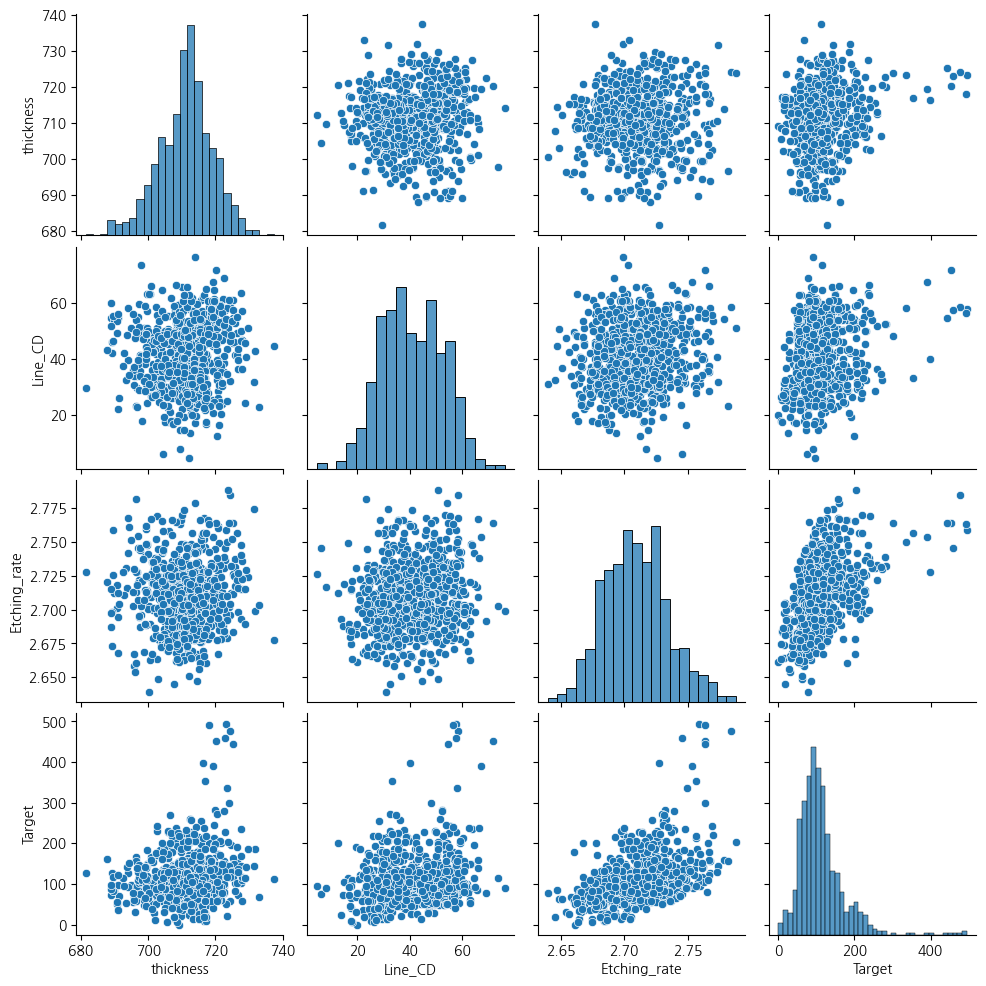

In [10]:
# 숫자형 데이터 변수( 주요 변수 )의 산점도를 확인해보자
# 두께, 라인, 속도, 불량

df2 = df1[['thickness', 'Line_CD', 'Etching_rate', 'Target']]
sns.pairplot(data=df2)

<Axes: xlabel='Target'>

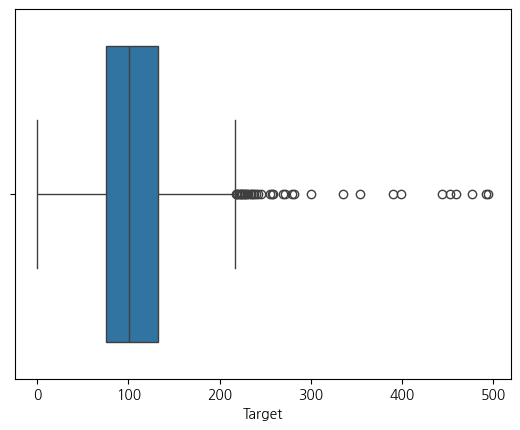

In [11]:
sns.boxplot(data=df1, x='Target')

### [해석]

### 200개 이후에 표시된 내용은 이상치로 확인되었다.

<Axes: xlabel='Error_message', ylabel='count'>

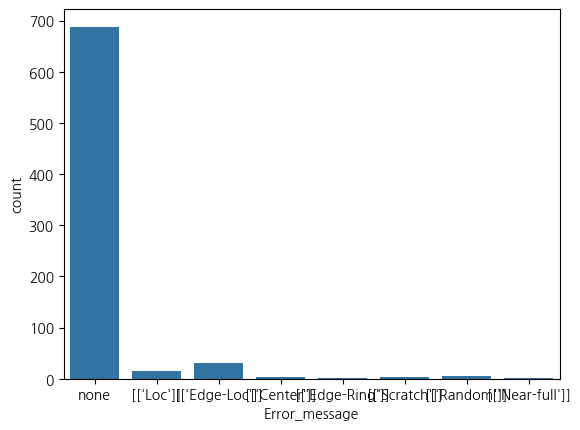

In [12]:
# 범주형 데이터를 확인해보자

sns.countplot(data=df1, x='Error_message')

<Axes: xlabel='count', ylabel='Error_message'>

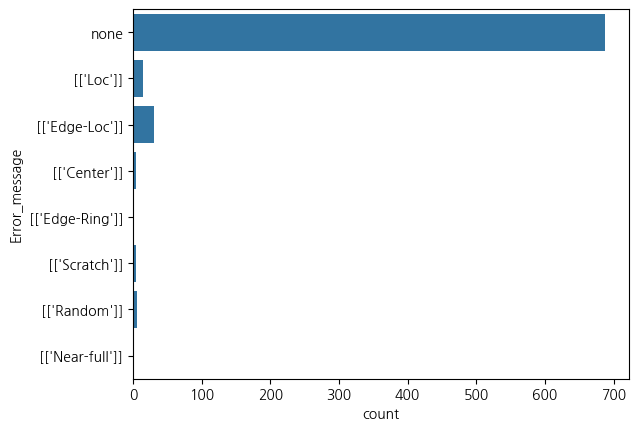

In [13]:
# x축에 이름이 겹쳐보이는 현상이 발생되어 축을 변경해보자

sns.countplot(data=df1, y='Error_message')

<Axes: xlabel='count', ylabel='Error_message'>

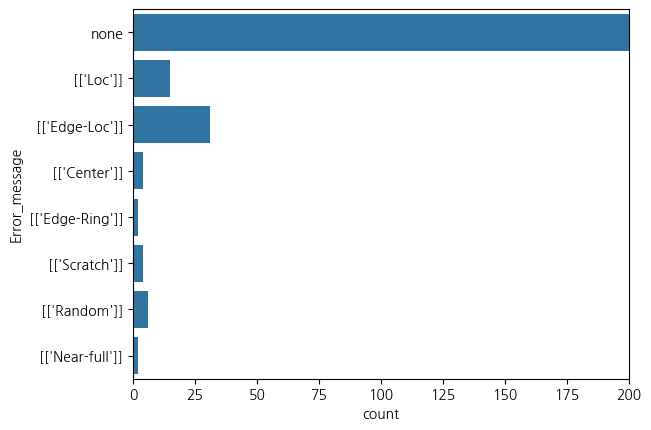

In [14]:
# none을 제외한 나머지에 대한 내용을 확인하기 어렵다.
# x축의 범위를 조정해 자세히 확인해보자.

plt.xlim([0,200])
sns.countplot(data=df1, y='Error_message')

<Axes: xlabel='count', ylabel='Error_message'>

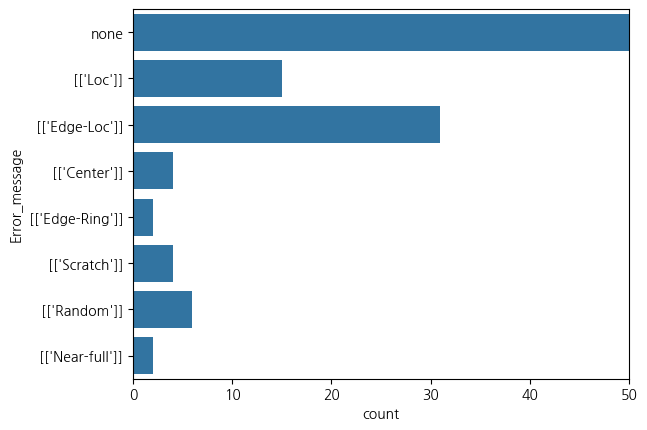

In [15]:
# 범위를 50으로 조정해 다시 확인해보자

plt.xlim([0,50])
sns.countplot(data=df1, y='Error_message')

In [16]:
# 공정시간, 보강여부
df1[['Oxid_time', 'Reinforcement']]

,Oxid_time,Reinforcement
0,62.0,True
1,137.0,True
2,128.0,False
3,90.0,False
4,98.0,False
...,...,...
747,21.0,False
748,22.0,False
749,21.0,False
750,22.0,False


In [17]:
# 공정시간, 보강여부, 두께
df1[['Oxid_time', 'Reinforcement', 'thickness']]

,Oxid_time,Reinforcement,thickness
0,62.0,True,699.443
1,137.0,True,696.792
2,128.0,False,705.471
3,90.0,False,710.772
4,98.0,False,716.975
...,...,...,...
747,21.0,False,708.586
748,22.0,False,712.936
749,21.0,False,715.498
750,22.0,False,707.179


In [18]:
df_oxid = df1[['Oxid_time', 'Reinforcement', 'thickness']]

# pivot을 이용해 평균값을 확인해보자
df_oxid.pivot_table(index='Reinforcement', values='Oxid_time')

,Oxid_time
Reinforcement,
False,124.600587
True,112.042254


<Axes: xlabel='Reinforcement', ylabel='Oxid_time'>

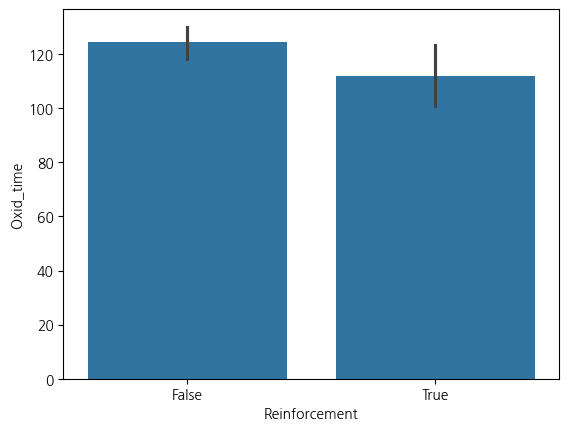

In [19]:
# 범주형 데이터 시각화를 진행해보자

sns.barplot(data=df_oxid, x='Reinforcement', y='Oxid_time')

### [해석]

### 실제 차이가 많아 보이지 않는다.
### 단순히 막대그래프로 비교하기는 어려워 보인다.(가운데 막대는 신뢰구간을 나타낸다)

<Axes: xlabel='Reinforcement', ylabel='Oxid_time'>

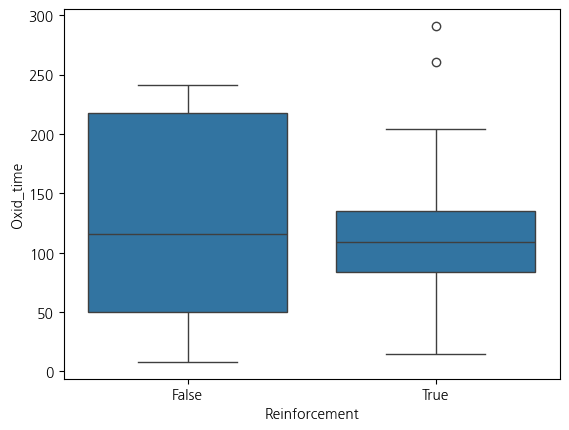

In [20]:
# box plot를 이용해 시각화를 진행해보자

sns.boxplot(data=df_oxid, x='Reinforcement', y='Oxid_time')

### [해석]

### 데이터의 분포와 중간값을 확인할 수 있다.
### 막대그래프 보다는 좀 더 직관적으로 표현된다.

### 그러나 변수가 차이가 없어보인다.
### 가설검증을 통해 진짜 차이가 있는지 없는지를 확인하고 넘어가야 한다.
### 단순한 데이터의 결과만을 가지고 판단하는 것이 아니라 도메인 전문가의 현장경험과 지식이 반영된 해석을 해야한다.

<Axes: xlabel='Reinforcement', ylabel='Target'>

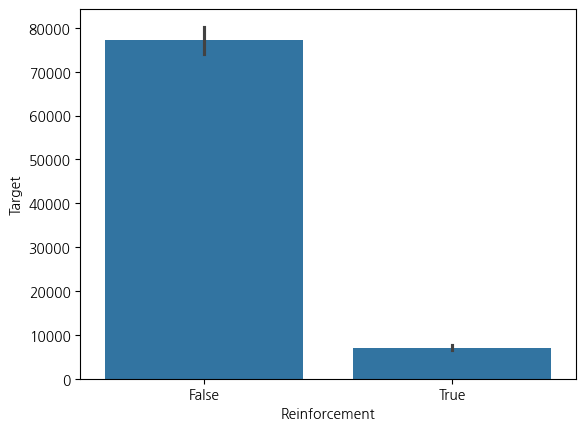

In [21]:
# 불량개수의 합을 확인해보자

sns.barplot(data=df1, x='Reinforcement', y='Target', estimator=sum)

<Axes: xlabel='Etching_rate', ylabel='Target'>

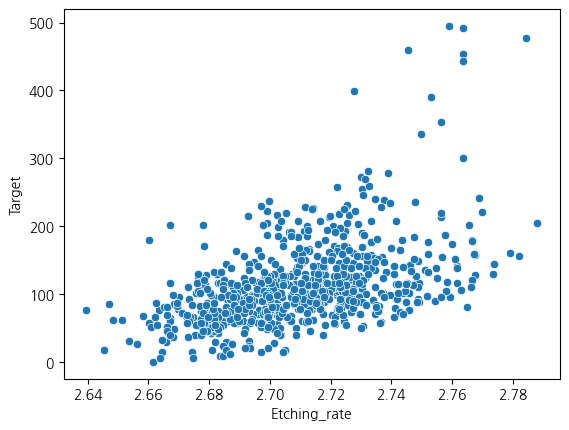

In [22]:
# 분석계획에서 정의된 목적
# 데이터의 상관관계를 확인하기 위해 산점도 그래프를 그려보자

df2 = df1[['Etching_rate', 'Target']]

sns.scatterplot(data=df2, x='Etching_rate', y='Target')

# [해석]
# Etching_rate가 높아질 수록 불량률도 높아지는 경향이 있어보인다.

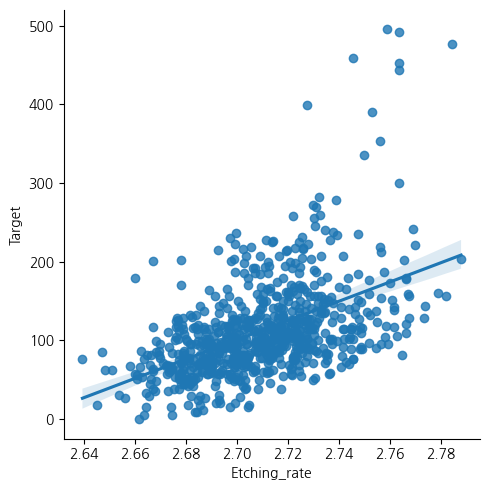

In [23]:
# 추세선을 추가해 다시 확인해보자.
sns.lmplot(data=df2, x='Etching_rate', y='Target')

# [해석]
# 우선 양의 상관관계( correlation )를 가지고 있는것으로 확인되었다.

In [24]:
# 상관계수를 추가적으로 확인해보자.
# 상관 계수 : +1 양의 상관 관계 / -1 음의 상관 관계

df2.corr()

,Etching_rate,Target
Etching_rate,1.000000,0.498164
Target,0.498164,1.000000


# 상관계수를 통해 양의 상관관계가 있다는 것을 수치로 확인했다.

In [25]:
import pandas as pd

# 숫자형 열만 선택하여 상관관계 계산
numeric_cols = df1.select_dtypes(include=['float64', 'int64'])

display(numeric_cols.corr())

,Unnamed: 0,Ox_Chamber,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Unnamed: 0_x,photo_soft_Chamber,resist_target,...,Flux90s,Flux160s,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,target_binom
Unnamed: 0,1.000000,0.028287,0.120478,0.094167,0.557330,-0.058885,0.379970,1.000000,0.014480,-0.242649,...,-0.378850,-0.393487,-0.095423,0.136296,0.459637,-0.020383,-0.050839,0.011598,0.015027,0.089737
Ox_Chamber,0.028287,1.000000,0.015082,-0.020463,0.012177,-0.014027,0.020858,0.028287,0.014048,-0.065834,...,0.005893,-0.008850,0.001956,-0.048901,-0.003799,0.019302,-0.001014,0.034577,-0.020888,-0.011271
Temp_OXid,0.120478,0.015082,1.000000,0.808618,0.019374,-0.789694,0.075231,0.120478,0.005157,0.136295,...,0.039797,0.039550,0.029139,-0.045169,-0.042307,-0.362360,-0.384507,-0.357707,-0.103644,-0.140847
ppm,0.094167,-0.020463,0.808618,1.000000,0.014908,-0.798779,0.086830,0.094167,0.011904,0.145581,...,0.032034,0.046675,0.038294,-0.044558,-0.020014,-0.353666,-0.357649,-0.370037,-0.081662,-0.131122
Pressure,0.557330,0.012177,0.019374,0.014908,1.000000,0.060185,0.356352,0.557330,0.011329,-0.098289,...,-0.265183,-0.286006,-0.064576,0.147200,0.352788,0.148231,-0.109303,0.152702,0.192317,0.159968
Oxid_time,-0.058885,-0.014027,-0.789694,-0.798779,0.060185,1.000000,-0.051174,-0.058885,0.012470,-0.140182,...,-0.064864,-0.068963,-0.033934,0.045279,0.046933,0.391378,0.324919,0.354968,0.111720,0.144595
thickness,0.379970,0.020858,0.075231,0.086830,0.356352,-0.051174,1.000000,0.379970,-0.054319,-0.017881,...,-0.233721,-0.185572,0.009723,0.116286,0.228411,0.099150,-0.193867,0.113594,0.191033,0.155299
Unnamed: 0_x,1.000000,0.028287,0.120478,0.094167,0.557330,-0.058885,0.379970,1.000000,0.014480,-0.242649,...,-0.378850,-0.393487,-0.095423,0.136296,0.459637,-0.020383,-0.050839,0.011598,0.015027,0.089737
photo_soft_Chamber,0.014480,0.014048,0.005157,0.011904,0.011329,0.012470,-0.054319,0.014480,1.000000,-0.042220,...,0.031363,-0.013933,0.000418,-0.047409,-0.017866,-0.009011,-0.006106,0.007111,-0.007206,0.016473
resist_target,-0.242649,-0.065834,0.136295,0.145581,-0.098289,-0.140182,-0.017881,-0.242649,-0.042220,1.000000,...,0.058208,0.041325,-0.003513,-0.031594,-0.166209,-0.121949,-0.093531,-0.109441,0.255690,0.162880


In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752 entries, 0 to 751
Data columns (total 60 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           752 non-null    int64  
 1   Ox_Chamber           752 non-null    int64  
 2   process              752 non-null    object 
 3   type                 752 non-null    object 
 4   Temp_OXid            752 non-null    float64
 5   Vapor                752 non-null    object 
 6   ppm                  752 non-null    float64
 7   Pressure             752 non-null    float64
 8   Oxid_time            752 non-null    float64
 9   thickness            752 non-null    float64
 10  No_Die               752 non-null    object 
 11  Reinforcement        752 non-null    bool   
 12  Unnamed: 0_x         752 non-null    int64  
 13  photo_soft_Chamber   752 non-null    int64  
 14  process 2            752 non-null    object 
 15  resist_target        752 non-null    flo

In [27]:
numeric_cols = df1.select_dtypes(include=['float64', 'int64'])
display(numeric_cols.corr())

,Unnamed: 0,Ox_Chamber,Temp_OXid,ppm,Pressure,Oxid_time,thickness,Unnamed: 0_x,photo_soft_Chamber,resist_target,...,Flux90s,Flux160s,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,target_binom
Unnamed: 0,1.000000,0.028287,0.120478,0.094167,0.557330,-0.058885,0.379970,1.000000,0.014480,-0.242649,...,-0.378850,-0.393487,-0.095423,0.136296,0.459637,-0.020383,-0.050839,0.011598,0.015027,0.089737
Ox_Chamber,0.028287,1.000000,0.015082,-0.020463,0.012177,-0.014027,0.020858,0.028287,0.014048,-0.065834,...,0.005893,-0.008850,0.001956,-0.048901,-0.003799,0.019302,-0.001014,0.034577,-0.020888,-0.011271
Temp_OXid,0.120478,0.015082,1.000000,0.808618,0.019374,-0.789694,0.075231,0.120478,0.005157,0.136295,...,0.039797,0.039550,0.029139,-0.045169,-0.042307,-0.362360,-0.384507,-0.357707,-0.103644,-0.140847
ppm,0.094167,-0.020463,0.808618,1.000000,0.014908,-0.798779,0.086830,0.094167,0.011904,0.145581,...,0.032034,0.046675,0.038294,-0.044558,-0.020014,-0.353666,-0.357649,-0.370037,-0.081662,-0.131122
Pressure,0.557330,0.012177,0.019374,0.014908,1.000000,0.060185,0.356352,0.557330,0.011329,-0.098289,...,-0.265183,-0.286006,-0.064576,0.147200,0.352788,0.148231,-0.109303,0.152702,0.192317,0.159968
Oxid_time,-0.058885,-0.014027,-0.789694,-0.798779,0.060185,1.000000,-0.051174,-0.058885,0.012470,-0.140182,...,-0.064864,-0.068963,-0.033934,0.045279,0.046933,0.391378,0.324919,0.354968,0.111720,0.144595
thickness,0.379970,0.020858,0.075231,0.086830,0.356352,-0.051174,1.000000,0.379970,-0.054319,-0.017881,...,-0.233721,-0.185572,0.009723,0.116286,0.228411,0.099150,-0.193867,0.113594,0.191033,0.155299
Unnamed: 0_x,1.000000,0.028287,0.120478,0.094167,0.557330,-0.058885,0.379970,1.000000,0.014480,-0.242649,...,-0.378850,-0.393487,-0.095423,0.136296,0.459637,-0.020383,-0.050839,0.011598,0.015027,0.089737
photo_soft_Chamber,0.014480,0.014048,0.005157,0.011904,0.011329,0.012470,-0.054319,0.014480,1.000000,-0.042220,...,0.031363,-0.013933,0.000418,-0.047409,-0.017866,-0.009011,-0.006106,0.007111,-0.007206,0.016473
resist_target,-0.242649,-0.065834,0.136295,0.145581,-0.098289,-0.140182,-0.017881,-0.242649,-0.042220,1.000000,...,0.058208,0.041325,-0.003513,-0.031594,-0.166209,-0.121949,-0.093531,-0.109441,0.255690,0.162880


# 일반적으로 위의 결과를 통해 상관관계가 높은 변수를 확인한 후 시각화를 진행한다.

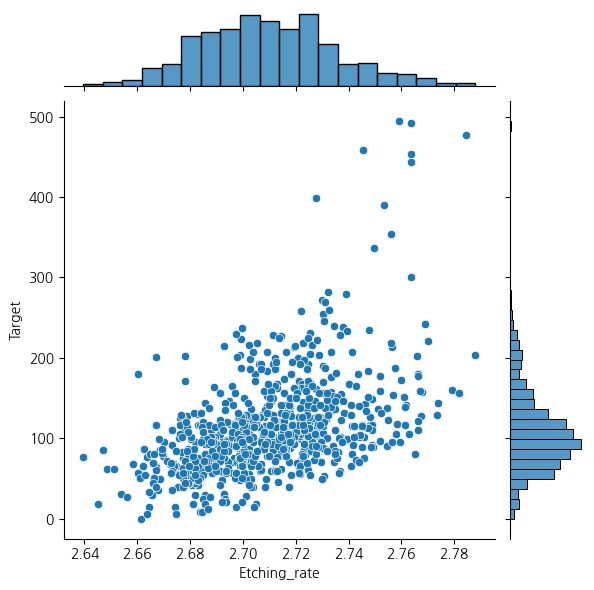

In [28]:
# 산점도와 분포를 함께 확인해보자.

sns.jointplot(data=df2, x='Etching_rate', y='Target')

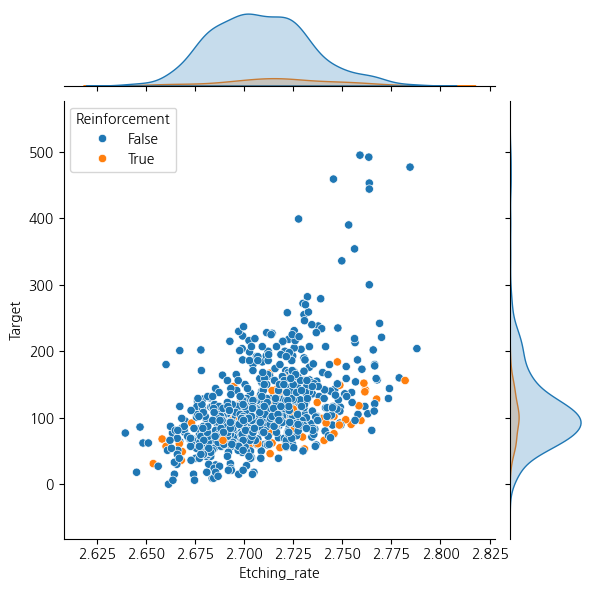

In [29]:
sns.jointplot(data=df1, x='Etching_rate', y='Target', hue='Reinforcement')

<Axes: xlabel='Ox_Chamber', ylabel='Target'>

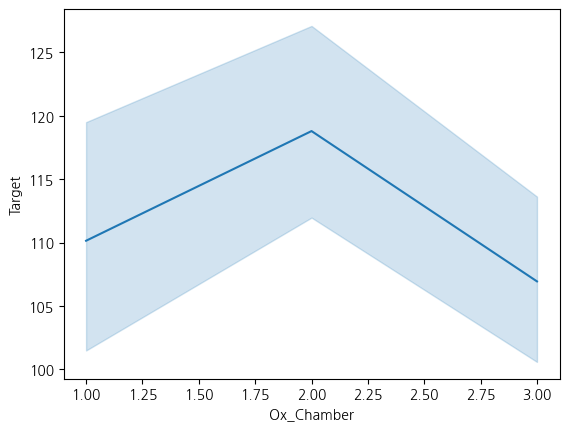

In [30]:
sns.lineplot(data=df1, x='Ox_Chamber', y='Target')

# 챔버별로 서열이 정해져있지 않지만, 시간과 같은 연속성 데이터를 확인하기 좋은 시각화기법

## 2. 공정 경로 별 부하량 확인하기

##     데이터 분석 계획 수립 : 경로 별 불량 개수 계산을 통한 공정 경로 부하량 확인

In [31]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [32]:
df1 = pd.read_csv(github_csv_url + '/preprocessing_data.csv')

df1.head()

,Unnamed: 0,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,target_binom,Chamber_Route
0,0,1,Oxidation,dry,1138.979159,O2,32.80,0.200,62.0,699.443,...,3.002593e+17,6.000007e+17,31574.410,102.847,885.0,154,96,none,0.0,route_11133
1,1,1,Oxidation,dry,1218.184551,O2,31.86,0.194,137.0,696.792,...,3.017903e+17,6.000012e+17,31580.213,104.323,919.0,154,102,none,0.0,route_11222
2,2,1,Oxidation,dry,1062.467808,O2,39.51,0.217,128.0,705.471,...,2.994231e+17,6.000002e+17,32162.414,100.605,916.0,155,95,none,0.0,route_11311
3,3,1,Oxidation,dry,1114.704773,O2,32.88,0.201,90.0,710.772,...,2.991354e+17,6.000003e+17,32874.925,101.739,911.0,156,117,none,0.0,route_12111
4,4,1,Oxidation,dry,989.411946,O2,38.11,0.204,98.0,716.975,...,3.005576e+17,6.000013e+17,30985.928,106.422,872.0,155,143,none,0.0,route_12222


In [33]:
# 경로별로 생산된 웨이퍼를 계산하기 위해 별도 컬럼(count)을 세팅한다.

df1['count'] = 1

In [34]:
df1

,Unnamed: 0,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,...,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,target_binom,Chamber_Route,count
0,0,1,Oxidation,dry,1138.979159,O2,32.80,0.200,62.0,699.443,...,6.000007e+17,31574.410,102.847,885.0,154,96,none,0.0,route_11133,1
1,1,1,Oxidation,dry,1218.184551,O2,31.86,0.194,137.0,696.792,...,6.000012e+17,31580.213,104.323,919.0,154,102,none,0.0,route_11222,1
2,2,1,Oxidation,dry,1062.467808,O2,39.51,0.217,128.0,705.471,...,6.000002e+17,32162.414,100.605,916.0,155,95,none,0.0,route_11311,1
3,3,1,Oxidation,dry,1114.704773,O2,32.88,0.201,90.0,710.772,...,6.000003e+17,32874.925,101.739,911.0,156,117,none,0.0,route_12111,1
4,4,1,Oxidation,dry,989.411946,O2,38.11,0.204,98.0,716.975,...,6.000013e+17,30985.928,106.422,872.0,155,143,none,0.0,route_12222,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,845,3,Oxidation,wet,1280.687973,H2O,45.19,0.214,21.0,708.586,...,5.999986e+17,32252.961,101.177,868.0,152,84,none,0.0,route_33111,1
748,846,3,Oxidation,wet,1275.153349,H2O,45.08,0.215,22.0,712.936,...,5.999991e+17,32253.818,100.736,868.0,151,105,none,0.0,route_33222,1
749,847,3,Oxidation,wet,1275.182502,H2O,45.10,0.214,21.0,715.498,...,6.000003e+17,32248.621,101.503,868.0,152,78,none,0.0,route_33333,1
750,848,1,Oxidation,wet,1268.105427,H2O,45.07,0.215,22.0,707.179,...,6.000003e+17,32241.426,101.061,867.0,152,42,none,0.0,route_11133,1


In [35]:
# index : 구분하고자 하는 항목
# values : 계산하고자 하는 값
# aggfunc : 계산하려는 통계 값

df1.pivot_table(index='Chamber_Route', values='count', aggfunc='sum')

,count
Chamber_Route,
route_11111,15
route_11133,13
route_11222,25
route_11311,17
route_11333,14
route_12111,18
route_12133,14
route_12222,20
route_12311,15


In [36]:
# count 개수대로 정렬

df1_chamber_route = df1.pivot_table(index='Chamber_Route', values='count', aggfunc='sum')

df1_chamber_route.sort_values(by='count', ascending=False)

,count
Chamber_Route,
route_23222,34
route_32222,30
route_22222,29
route_21222,26
route_13222,26
route_11222,25
route_31222,23
route_33222,22
route_12222,20


In [37]:
df1_chamber_route

,count
Chamber_Route,
route_11111,15
route_11133,13
route_11222,25
route_11311,17
route_11333,14
route_12111,18
route_12133,14
route_12222,20
route_12311,15


In [38]:
df1_chamber_route.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, route_11111 to route_33333
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   count   45 non-null     int64
dtypes: int64(1)
memory usage: 720.0+ bytes


In [39]:
# df1_chamber_route 데이터프레임에  Chamber_Route가 인덱스로 설정되어 있다.

df1_chamber_route = df1.pivot_table(index='Chamber_Route', values='count', aggfunc='sum').reset_index()

<Axes: xlabel='Chamber_Route', ylabel='count'>

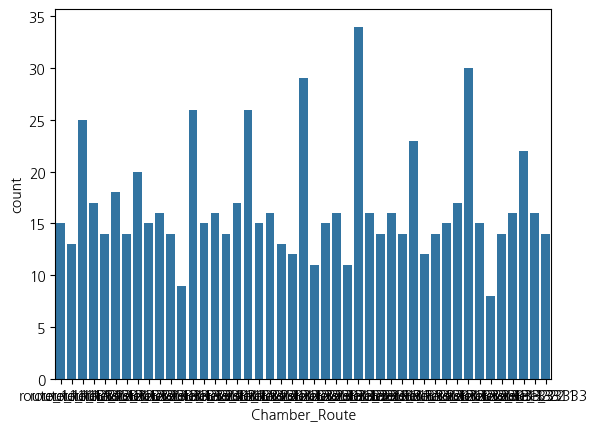

In [40]:
sns.barplot(data=df1_chamber_route, x='Chamber_Route', y='count')

<Axes: xlabel='count', ylabel='Chamber_Route'>

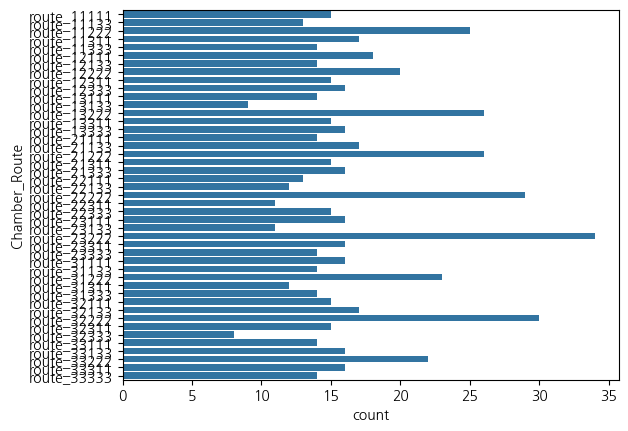

In [41]:
sns.barplot(data=df1_chamber_route, y='Chamber_Route', x='count')

<Axes: xlabel='count', ylabel='Chamber_Route'>

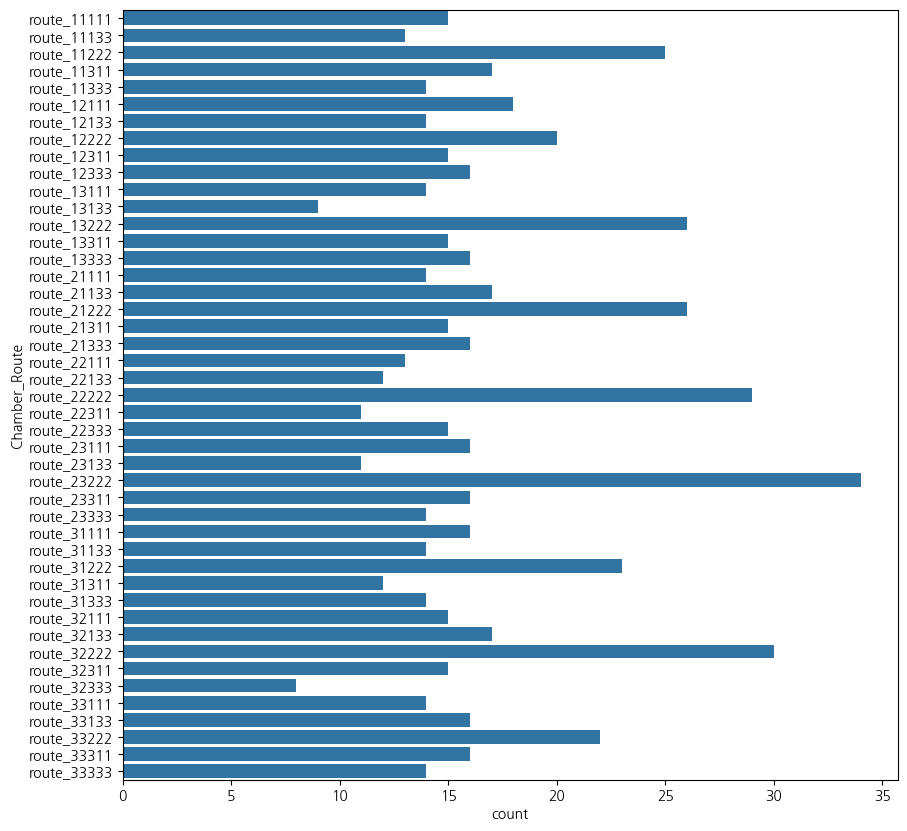

In [42]:
plt.figure(figsize=[10,10])
sns.barplot(data=df1_chamber_route, y='Chamber_Route', x='count')

Text(0.5, 1.0, '경로 별 작업이 진행된 Wafer 수')

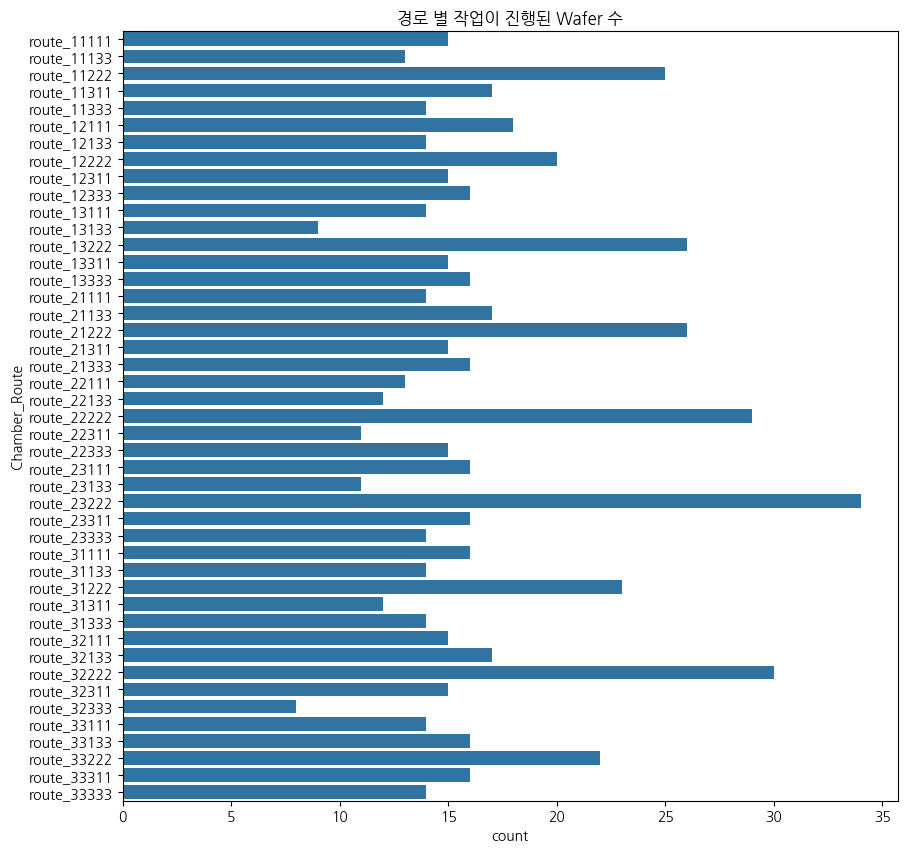

In [43]:
plt.figure(figsize=[10,10])
sns.barplot(data=df1_chamber_route, y='Chamber_Route', x='count')
plt.title('경로 별 작업이 진행된 Wafer 수')

In [44]:
# 그래프를 정렬된 상태로 다시 그려보자

df1_chamber_route_sorting = df1_chamber_route.sort_values(by='count', ascending=False)
order_list = df1_chamber_route_sorting['Chamber_Route'].tolist()
# Wafer 작업량이 많은 Chamber 순으로 나열된 리스트 선언
order_list

['route_23222',
 'route_32222',
 'route_22222',
 'route_21222',
 'route_13222',
 'route_11222',
 'route_31222',
 'route_33222',
 'route_12222',
 'route_12111',
 'route_32133',
 'route_21133',
 'route_11311',
 'route_23311',
 'route_31111',
 'route_33133',
 'route_33311',
 'route_21333',
 'route_23111',
 'route_13333',
 'route_12333',
 'route_32311',
 'route_13311',
 'route_21311',
 'route_32111',
 'route_12311',
 'route_11111',
 'route_22333',
 'route_11333',
 'route_33333',
 'route_33111',
 'route_12133',
 'route_13111',
 'route_21111',
 'route_31333',
 'route_23333',
 'route_31133',
 'route_22111',
 'route_11133',
 'route_31311',
 'route_22133',
 'route_23133',
 'route_22311',
 'route_13133',
 'route_32333']

Text(0.5, 1.0, '경로 별 작업이 진행된 Wafer 수')

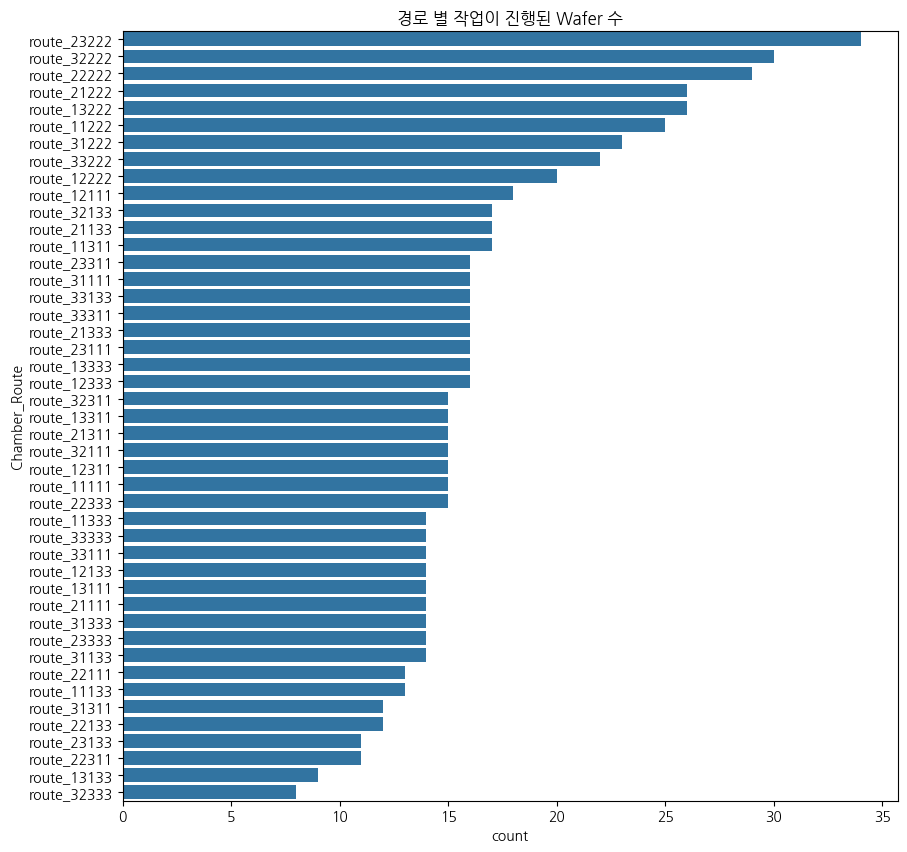

In [45]:
plt.figure(figsize=[10,10])
sns.barplot(data=df1_chamber_route, y='Chamber_Route', x='count', order = order_list)
plt.title('경로 별 작업이 진행된 Wafer 수')

In [46]:
# 경로 중 불량이 많은 경로는 어떤것인지 확인해보자
# Wafer 1개당 2000개의 칩이 있으면 그중 불량이 발생한 개수 : Target

df1.pivot_table(index='Chamber_Route', values='Target', aggfunc='sum')

,Target
Chamber_Route,
route_11111,1415
route_11133,1367
route_11222,2281
route_11311,1811
route_11333,1203
route_12111,1677
route_12133,1519
route_12222,2835
route_12311,1253


In [47]:
# 불량이 발생한 Wafer의 개수 : count

df1.pivot_table(index='Chamber_Route', values=['Target','count'], aggfunc='sum')

,Target,count
Chamber_Route,,
route_11111,1415,15
route_11133,1367,13
route_11222,2281,25
route_11311,1811,17
route_11333,1203,14
route_12111,1677,18
route_12133,1519,14
route_12222,2835,20
route_12311,1253,15


In [48]:
df1_Chamber_error = df1.pivot_table(index='Chamber_Route', values=['Target','count'], aggfunc='sum').reset_index()

In [49]:
# 1개의 웨이퍼 당 발생하는 불량칩의 개수를 확인해보자

df1_Chamber_error['Target'] / df1_Chamber_error['count']

,0
0,94.333333
1,105.153846
2,91.240000
3,106.529412
4,85.928571
5,93.166667
6,108.500000
7,141.750000
8,83.533333
9,134.500000


In [50]:
# error_rate : 하나의 Wafer가 생산될 때 발생한 불량칩의 평균값을 공정 경로별로 계산해보자

df1_Chamber_error['error_rate'] = df1_Chamber_error['Target'] / df1_Chamber_error['count']
df1_Chamber_error

,Chamber_Route,Target,count,error_rate
0,route_11111,1415,15,94.333333
1,route_11133,1367,13,105.153846
2,route_11222,2281,25,91.240000
3,route_11311,1811,17,106.529412
4,route_11333,1203,14,85.928571
5,route_12111,1677,18,93.166667
6,route_12133,1519,14,108.500000
7,route_12222,2835,20,141.750000
8,route_12311,1253,15,83.533333
9,route_12333,2152,16,134.500000


In [51]:
df1_Chamber_error.sort_values(by='error_rate', ascending=False)

,Chamber_Route,Target,count,error_rate
39,route_32333,1561,8,195.125000
26,route_23133,1792,11,162.909091
11,route_13133,1452,9,161.333333
21,route_22133,1895,12,157.916667
7,route_12222,2835,20,141.750000
15,route_21111,1942,14,138.714286
9,route_12333,2152,16,134.500000
19,route_21333,2096,16,131.000000
17,route_21222,3358,26,129.153846
33,route_31311,1548,12,129.000000


# [해석]
# 작업부하와 오류는 크게 상관관계가 없어 보인다